<a href="https://colab.research.google.com/github/Nikhilsankhyan0/Agrisheild-AI/blob/main/NLP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
# 1. Importing Libraries

import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

# NLTK
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# SpaCy
import spacy

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

In [39]:
# 2. Downloading NLTK Resources

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [40]:
# 3. Load SpaCy Model

nlp = spacy.load("en_core_web_sm")

In [41]:
# 4. Load Dataset
from google.colab import drive
drive.mount('/content/drive')

file_path="/content/drive/MyDrive/twitter_training.csv"

df = pd.read_csv(
    file_path,
    header=None
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
# 5. Give meaningful column names

df.columns = [
    "Tweet_ID",
    "Entity",
    "Sentiment",
    "Text"
]

print("\nFirst five records:")
print(df.head())


First five records:
   Tweet_ID       Entity Sentiment  \
0      2401  Borderlands  Positive   
1      2401  Borderlands  Positive   
2      2401  Borderlands  Positive   
3      2401  Borderlands  Positive   
4      2401  Borderlands  Positive   

                                                Text  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  


In [43]:
# 6. Basic Dataset Information

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSentiment Distribution:")
print(df["Sentiment"].value_counts())


Dataset Shape:
(74682, 4)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet_ID   74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB
None

Missing Values:
Tweet_ID       0
Entity         0
Sentiment      0
Text         686
dtype: int64

Sentiment Distribution:
Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


In [44]:
# 6. Basic Dataset Information

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSentiment Distribution:")
print(df["Sentiment"].value_counts())


Dataset Shape:
(74682, 4)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet_ID   74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB
None

Missing Values:
Tweet_ID       0
Entity         0
Sentiment      0
Text         686
dtype: int64

Sentiment Distribution:
Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


In [45]:
# 7. Remove Missing Values

df = df.dropna(
    subset=["Text", "Sentiment"]
)

print("\nDataset after removing missing values:")
print(df.shape)


Dataset after removing missing values:
(73996, 4)


In [46]:
# 8. Remove Irrelevant Class

df = df[
    df["Sentiment"].isin(
        ["Positive", "Negative", "Neutral"]
    )
]

print("\nSentiment distribution after removing irrelevant classes:")
print(df["Sentiment"].value_counts())


Sentiment distribution after removing irrelevant classes:
Sentiment
Negative    22358
Positive    20655
Neutral     18108
Name: count, dtype: int64


In [47]:
# 9. Text Preprocessing Setup

stop_words = set(
    stopwords.words("english")
)

lemmatizer = WordNetLemmatizer()

In [48]:
# 10. Text Preprocessing Function

def clean_text(text):
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove mentions
    text = re.sub(r"@\W+", "", text)

    # Remove hashtag symbol
    text = re.sub(r"#", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    # Tokenization and stopword removal
    words = [
        word
        for word in text.split()
        if word not in stop_words
    ]

    # Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return " ".join(words)

In [49]:
# 11. Original and Cleaned Text

df["Clean_Text"] = df["Text"].apply(
    clean_text
)

print("Original and Cleaned Text:")
print(
    df[
        ["Text", "Clean_Text"]
    ].head()
)

Original and Cleaned Text:
                                                Text  \
0  im getting on borderlands and i will murder yo...   
1  I am coming to the borders and I will kill you...   
2  im getting on borderlands and i will kill you ...   
3  im coming on borderlands and i will murder you...   
4  im getting on borderlands 2 and i will murder ...   

                     Clean_Text  
0  im getting borderland murder  
1            coming border kill  
2    im getting borderland kill  
3   im coming borderland murder  
4  im getting borderland murder  


In [50]:
# 12. Remove Empty Text Records

df = df[
    df["Clean_Text"].str.strip() != ""
]

print("Dataset shape after removing empty text:")
print(df.shape)

Dataset shape after removing empty text:
(59762, 5)


In [51]:
# 13. SpaCy Preprocessing Function

def spacy_preprocess(text):
    doc = nlp(text)

    tokens = []

    for token in doc:
        if (
            not token.is_stop
            and not token.is_punct
            and not token.is_space
        ):
            tokens.append(
                token.lemma_.lower()
            )

    return " ".join(tokens)

In [52]:
# Use NLTK-cleaned text directly
df["Preprocessed_Text"] = df["Clean_Text"]

print("\nPreprocessed Text:")
print(
    df[
        ["Text", "Preprocessed_Text"]
    ].head(10)
)


Preprocessed Text:
                                                Text  \
0  im getting on borderlands and i will murder yo...   
1  I am coming to the borders and I will kill you...   
2  im getting on borderlands and i will kill you ...   
3  im coming on borderlands and i will murder you...   
4  im getting on borderlands 2 and i will murder ...   
5  im getting into borderlands and i can murder y...   
6  So I spent a few hours making something for fu...   
7  So I spent a couple of hours doing something f...   
8  So I spent a few hours doing something for fun...   
9  So I spent a few hours making something for fu...   

                                   Preprocessed_Text  
0                       im getting borderland murder  
1                                 coming border kill  
2                         im getting borderland kill  
3                        im coming borderland murder  
4                       im getting borderland murder  
5                       im gettin

In [53]:
# 15. Define Features and Targets

X = df["Preprocessed_Text"]
y = df["Sentiment"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
0    im getting borderland murder
1              coming border kill
2      im getting borderland kill
3     im coming borderland murder
4    im getting borderland murder
Name: Preprocessed_Text, dtype: object

Target:
0    Positive
1    Positive
2    Positive
3    Positive
4    Positive
Name: Sentiment, dtype: object


In [54]:
# 16. Split Data into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 47809
Testing samples: 11953


In [55]:
# 17. TF-IDF Feature Extraction

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

# Learn vocabulary from training data
X_train_tfidf = vectorizer.fit_transform(
    X_train
)

# Transform testing data
X_test_tfidf = vectorizer.transform(
    X_test
)

print("\nTF-IDF Training Shape:")
print(
    "Shape of X_train_tfidf:",
    X_train_tfidf.shape
)

print("\nTF-IDF Testing Shape:")
print(
    "Shape of X_test_tfidf:",
    X_test_tfidf.shape
)


TF-IDF Training Shape:
Shape of X_train_tfidf: (47809, 10000)

TF-IDF Testing Shape:
Shape of X_test_tfidf: (11953, 10000)


In [56]:
# 18. Create Naive Bayes Classifier

model = MultinomialNB()

In [57]:
# 19. Train the Model

model.fit(
    X_train_tfidf,
    y_train
)

print(
    "Model Training Completed Successfully."
)

Model Training Completed Successfully.


In [58]:
# 20. Make Predictions on Test Data

y_pred = model.predict(
    X_test_tfidf
)

print("Predictions completed successfully.")

Predictions completed successfully.


In [59]:
# 21. Calculate Accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy:")
print(f"{accuracy:.4f}")


Accuracy:
0.7575


In [60]:
# 21. Calculate Accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy:")
print(f"{accuracy:.4f}")


Accuracy:
0.7575


In [61]:
# 21. Calculate Accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy:")
print(f"{accuracy:.4f}")


Accuracy:
0.7575


In [62]:
# 22. Calculate Precision

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

print("\nPrecision:")
print(f"{precision:.4f}")


Precision:
0.7592


In [63]:
# 23. Calculate Recall

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

print("\nRecall:")
print(f"{recall:.4f}")


Recall:
0.7575


In [64]:
# 24. Calculate F1 Score

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("\nF1 Score:")
print(f"{f1:.4f}")


F1 Score:
0.7541


In [65]:
# 25. Classification Report

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)


Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.84      0.79      4385
     Neutral       0.78      0.61      0.68      3532
    Positive       0.75      0.80      0.78      4036

    accuracy                           0.76     11953
   macro avg       0.76      0.75      0.75     11953
weighted avg       0.76      0.76      0.75     11953



In [66]:
# 26. Confusion Matrix

labels = [
    "Positive",
    "Negative",
    "Neutral"
]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[3242  502  292]
 [ 400 3667  318]
 [ 683  704 2145]]


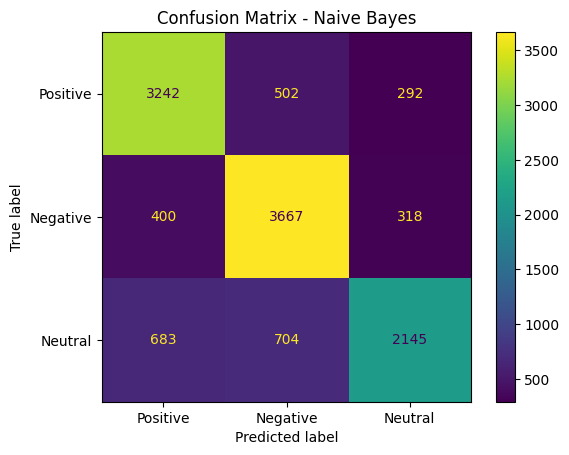

In [67]:
# 27. Display Confusion Matrix Graph

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()

plt.title(
    "Confusion Matrix - Naive Bayes"
)

plt.show()

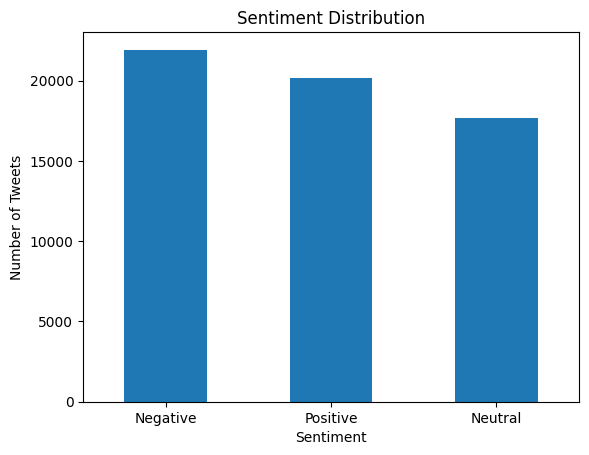

In [68]:
# 28. Sentiment Distribution Visualization

df["Sentiment"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Sentiment Distribution"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.xticks(
    rotation=0
)

plt.show()